# Part B — one cosinor caller, applied identically to both organisms

Replaces the two papers' own incommensurable calls. See `ANALYSIS_SPEC.md` PART B.

## Why this exists

Part A's amplitude comparison put two different quantities side by side: Ito's published
CV and Kushige's raw-recomputed CV, on two different array platforms with different noise
floors (H3). `src/07_fetch_vijayan_markson.py` fixed the 7942 side by fitting a single
explicit cosinor model to Vijayan/Markson's raw LL time course instead of trusting Ito's
summary indices -- but that only replaces one side. This notebook replaces the OTHER
side too: log2-transforms Kushige's raw N+ intensities and runs the SAME cosinor function
(imported from `07_fetch_vijayan_markson.py`, not re-derived) on them, so for the first
time in this project both organisms' amplitude and peak time come from one identical
procedure applied to raw values, not two papers' own analysis choices.

## Two things to know before trusting the output

1. Kushige's N+ intensities are NOT two-colour log-ratios like Vijayan/Markson -- they're
   background-subtracted single-channel intensities, strictly positive in the vast
   majority of cells. log2-transforming them (rather than carrying the raw CV across,
   H3's original sin) is what makes the amplitude commensurable with Vijayan's already-log2
   values: both become "log2 fold change around each gene's own mean", which IS a
   comparable quantity across platforms, unlike two raw CVs.
2. 684 of 128,064 readings (0.53%) are exactly 0.0 -- a real floor-of-detection value, not
   a rounding artifact (checked directly). log2(0) is undefined, so these are dropped
   per-gene before fitting rather than pseudocounted -- an arbitrary pseudocount would
   arbitrarily inflate that gene's apparent amplitude. Affects 464/5336 genes, almost all
   losing only 1-2 of 24 points; the cosinor's own n>=4 guard means no gene is silently
   underfit (worst case keeps 12/24 points).

Reads `data/processed/7942_ll_cosinor.csv` (from `07_fetch_vijayan_markson.py`) and
`Kushige2013_so2.xlsx` directly. Writes `data/processed/kushige_ll_cosinor.csv`,
`data/processed/rbh_recompare_vijayan.csv`, `data/processed/ab_comparison.csv`, and three
figures.

## Setup

Load the reusable Fisher-z CI helper from `src/amplitude_stats.py` (shared with Part A),
and load `cosinor()` straight out of `07_fetch_vijayan_markson.py` by file path rather
than re-typing it -- that script's filename starts with a digit so it can't be `import`ed
by name, and re-deriving the cosinor a second time is exactly what produced the sign-flip
bug logged in `hurdles.md` (2026-07-29) the first time it was re-derived.

In [1]:
from __future__ import annotations

import importlib.util
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as scipy_stats

def find_project_root(marker=".git"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}' above {p})")


REPO = find_project_root()
PROCESSED = REPO / "data" / "processed"
FIGURES = REPO / "figures"
FIGURES.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO / "src"))
from amplitude_stats import fisher_z_ci

_spec = importlib.util.spec_from_file_location("fetch_vijayan_markson", REPO / "src" / "07_fetch_vijayan_markson.py")
_fetch_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_fetch_mod)
cosinor = _fetch_mod.cosinor

LL_TIMEPOINTS = [4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
RNG = np.random.default_rng(20260730)
TEXT_SECONDARY, TEXT_PRIMARY = "#52514e", "#0b0b0b"

## Helper functions

- `fit_kushige_log2`: fits the shared cosinor to log2(Kushige N+ intensity) for every
  gene. `replicate=None` pools both 1st and 2nd series (24 points, used for the headline
  fit); `replicate="1st"`/`"2nd"` fits each series alone (12 points, used only for the B5
  reliability estimate -- two independent replicate fits to correlate against each other,
  the Anabaena-side analogue of Vijayan-vs-Markson).
- `circular_diff_signed` / `rayleigh_test`: the identical circular-statistics formulas
  `VersionB_AllOrthologs.ipynb` §4-5 uses (Zar's higher-order p correction), reused here
  rather than re-derived so the OLD and NEW phase numbers are directly comparable.

In [2]:
def fit_kushige_log2(kushige_raw: pd.DataFrame, replicate: str | None = None) -> pd.DataFrame:
    reps = [replicate] if replicate else ["1st", "2nd"]
    cols = [f"N+_{r}_LL{t}" for r in reps for t in LL_TIMEPOINTS]
    times = np.array([t for r in reps for t in LL_TIMEPOINTS], dtype=float)

    rows = []
    n_dropped_zero = 0
    for _, row in kushige_raw.iterrows():
        vals = row[cols].to_numpy(dtype=float)
        keep = vals > 0  # exact-zero = below detection floor, not log-transformable (see intro)
        n_dropped_zero += int((~keep).sum())
        res = cosinor(times[keep], np.log2(vals[keep]))
        res["locus_tag_anabaena"] = row["ORF No."]
        rows.append(res)
    out = pd.DataFrame(rows)
    label = f"anabaena_{replicate}" if replicate else "anabaena"
    out["amp_pct"] = out["amplitude"].rank(pct=True)
    out = out.add_suffix(f"_{label}").rename(columns={f"locus_tag_anabaena_{label}": "locus_tag_anabaena"})
    print(f"  {label}: fitted {len(out)} genes, {out[f'p_value_{label}'].lt(0.05).sum()} with p < 0.05, "
          f"{n_dropped_zero} zero-readings dropped across all genes")
    return out


def circular_diff_signed(a: np.ndarray, b: np.ndarray, period: float = 24) -> np.ndarray:
    return ((a - b + period / 2) % period) - period / 2


def rayleigh_test(delta_phi_h: np.ndarray, period: float = 24) -> dict:
    """Same formula as VersionB_AllOrthologs.ipynb Sec 5 -- Zar's higher-order p correction."""
    n = len(delta_phi_h)
    angles = 2 * np.pi * delta_phi_h / period
    C, S = np.sum(np.cos(angles)), np.sum(np.sin(angles))
    R = np.sqrt(C**2 + S**2)
    Rbar = R / n
    Z = n * Rbar**2
    p = np.exp(-Z) * (1 + (2 * Z - Z**2) / (4 * n)
                       - (24 * Z - 132 * Z**2 + 76 * Z**3 - 9 * Z**4) / (288 * n**2))
    p = min(max(p, 0.0), 1.0)
    mean_dir = np.degrees(np.arctan2(S, C)) / 360 * period
    return dict(n=n, Rbar=Rbar, Z=Z, p=p, mean_direction_h=mean_dir)

## 1. Kushige log2 cosinor fit (pooled + per-replicate for B5)

Fit the pooled series (headline amplitude/peak time) and each replicate series alone
(needed later for B5's disattenuation reliability estimate).

In [3]:
print("[1/6] Kushige log2 cosinor fit (pooled + per-replicate for B5)")
kushige_raw = pd.read_excel(REPO / "Kushige2013" / "Kushige2013_so2.xlsx", sheet_name="Sheet1", header=5)
fit_pooled = fit_kushige_log2(kushige_raw, replicate=None)
fit_1st = fit_kushige_log2(kushige_raw, replicate="1st")
fit_2nd = fit_kushige_log2(kushige_raw, replicate="2nd")
kushige_fit = fit_pooled.merge(fit_1st, on="locus_tag_anabaena").merge(fit_2nd, on="locus_tag_anabaena")
kushige_fit.to_csv(PROCESSED / "kushige_ll_cosinor.csv", index=False)
print(f"  wrote {PROCESSED / 'kushige_ll_cosinor.csv'}")

[1/6] Kushige log2 cosinor fit (pooled + per-replicate for B5)


/Users/jaemac/miniforge3/envs/genomics_arm64/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


  anabaena: fitted 5336 genes, 676 with p < 0.05, 684 zero-readings dropped across all genes


  anabaena_1st: fitted 5336 genes, 346 with p < 0.05, 90 zero-readings dropped across all genes


  anabaena_2nd: fitted 5336 genes, 429 with p < 0.05, 594 zero-readings dropped across all genes
  wrote /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/data/processed/kushige_ll_cosinor.csv


## 2. Join RBH pairs x Vijayan fit x Kushige log2 fit

Also carries each paper's own published calls as columns for comparison (never as
filters) -- required by B3.

In [4]:
print("\n[2/6] Join RBH pairs x Vijayan fit x Kushige log2 fit, plus each paper's own published calls")
rbh = pd.read_csv(PROCESSED / "rbh_orthologs.csv")
vijayan_fit = pd.read_csv(PROCESSED / "7942_ll_cosinor.csv")

ito_full = pd.read_excel(REPO / "Ito2009" / "Ito2009_sd1.xls", sheet_name="Table S1", header=5)
ito_full = ito_full.rename(columns={
    "7942ID": "locus_tag_7942", "Gene Name": "gene_symbol_7942",
    "Amplitude*": "published_amplitude_cv_7942", "Cycling property**": "published_tier_7942",
})[["locus_tag_7942", "gene_symbol_7942", "published_amplitude_cv_7942", "published_tier_7942"]]

kushige_meta = kushige_raw.rename(columns={
    "ORF No.": "locus_tag_anabaena", "Gene name": "gene_symbol_anabaena",
    "Cycling property (N+, n=2)*": "published_tier_anabaena",
})[["locus_tag_anabaena", "gene_symbol_anabaena", "published_tier_anabaena"]]

pairs = (
    rbh.merge(vijayan_fit, on="locus_tag_7942", how="left")
    .merge(kushige_fit, on="locus_tag_anabaena", how="left")
    .merge(ito_full, on="locus_tag_7942", how="left")
    .merge(kushige_meta, on="locus_tag_anabaena", how="left")
)
pairs = pairs.dropna(subset=["amplitude_vijayan", "amplitude_anabaena"]).copy()
print(f"  RBH pairs: {len(rbh)}; with a NEW cosinor fit on both sides: {len(pairs)}")


[2/6] Join RBH pairs x Vijayan fit x Kushige log2 fit, plus each paper's own published calls
  RBH pairs: 1846; with a NEW cosinor fit on both sides: 1811


## 3. B4a — amplitude vs amplitude, redone on the new fitted values

`amp_pct_vijayan` / `amp_pct_anabaena` already arrived via the merge above, each ranked
within its OWN full platform population (2715 / 5336 genes) before the join -- H3, the
same rule Part A used. No re-ranking needed here.

In [5]:
print("\n[3/6] B4a -- amplitude vs amplitude, redone on the new fitted values")
rho_new, p_new = scipy_stats.spearmanr(pairs["amplitude_vijayan"], pairs["amplitude_anabaena"])
n_new = len(pairs)
ci_lo_new, ci_hi_new = fisher_z_ci(rho_new, n_new)
print(f"  NEW global rho = {rho_new:+.3f}, p = {p_new:.3g}, n = {n_new}, "
      f"95% CI = [{ci_lo_new:+.3f}, {ci_hi_new:+.3f}]")
print(f"  OLD (Part A, Ito published calls): rho=+0.056, CI=[+0.010,+0.102], n=1787")


[3/6] B4a -- amplitude vs amplitude, redone on the new fitted values
  NEW global rho = +0.132, p = 1.73e-08, n = 1811, 95% CI = [+0.086, +0.177]
  OLD (Part A, Ito published calls): rho=+0.056, CI=[+0.010,+0.102], n=1787


## 4. B4b — circular phase-offset, redone on the new fitted peak times

Repeats `VersionB_AllOrthologs.ipynb` §4-6 (Δφ wrapped to ±12h, Rayleigh test, amplitude
overlay) on the new joint table -- but now on essentially every RBH pair, since Vijayan's
cosinor returns a peak time for every gene regardless of significance.

In [6]:
print("\n[4/6] B4b -- circular phase-offset, redone on the new fitted peak times")
ph = pairs.dropna(subset=["peak_time_h_vijayan", "peak_time_h_anabaena"]).copy()
ph["delta_phi_h"] = circular_diff_signed(ph["peak_time_h_vijayan"].to_numpy(), ph["peak_time_h_anabaena"].to_numpy())
n_phase = len(ph)
ray = rayleigh_test(ph["delta_phi_h"].to_numpy())
print(f"  NEW phase set: n={n_phase} (vs 565 under the old Ito peak-time join)")
print(f"  Rayleigh: R-bar={ray['Rbar']:.4f}, Z={ray['Z']:.2f}, p={ray['p']:.3e}, "
      f"mean direction={ray['mean_direction_h']:+.2f}h")
print(f"  OLD (VersionB, Ito peak times): R-bar=0.167, p=1.4e-07, n=565")

ph["weaker_amp_pct"] = ph[["amp_pct_vijayan", "amp_pct_anabaena"]].min(axis=1)
rho_amp_phase, p_amp_phase = scipy_stats.spearmanr(ph["weaker_amp_pct"], ph["delta_phi_h"].abs())
print(f"  |delta_phi| vs weaker-side amplitude percentile: rho={rho_amp_phase:+.3f}, p={p_amp_phase:.3g} "
      f"(OLD: rho=+0.014, p=0.74)")


[4/6] B4b -- circular phase-offset, redone on the new fitted peak times
  NEW phase set: n=1811 (vs 565 under the old Ito peak-time join)
  Rayleigh: R-bar=0.0915, Z=15.17, p=2.514e-07, mean direction=-3.29h
  OLD (VersionB, Ito peak times): R-bar=0.167, p=1.4e-07, n=565
  |delta_phi| vs weaker-side amplitude percentile: rho=-0.048, p=0.0418 (OLD: rho=+0.014, p=0.74)


## 5. B5 — reliability and disattenuation

H4, upgraded from "permanently blocked" to executable once the Markson replicate was
identified (`hurdles.md`, 2026-07-29). Both raw and disattenuated rho are reported —
never replace the raw number with the corrected one, and the CI widens, not narrows.

In [7]:
print("\n[5/6] B5 -- reliability and disattenuation")
rel_7942 = vijayan_fit["amplitude_vijayan"].corr(vijayan_fit["amplitude_markson"], method="spearman")
rel_anabaena = kushige_fit["amplitude_anabaena_1st"].corr(kushige_fit["amplitude_anabaena_2nd"], method="spearman")
print(f"  7942-side reliability (Vijayan vs Markson, n={vijayan_fit['amplitude_markson'].notna().sum()}): "
      f"rho={rel_7942:+.3f}")
print(f"  Anabaena-side reliability (1st vs 2nd replicate, n={len(kushige_fit)}): rho={rel_anabaena:+.3f}")
disatten_factor = 1 / np.sqrt(max(rel_7942, 1e-6) * max(rel_anabaena, 1e-6))
rho_disatten = rho_new * disatten_factor
ci_lo_disatten, ci_hi_disatten = ci_lo_new * disatten_factor, ci_hi_new * disatten_factor
print(f"  attenuation factor sqrt(rel_7942 * rel_anabaena) = {1/disatten_factor:.3f}")
print(f"  RAW rho={rho_new:+.3f} [{ci_lo_new:+.3f},{ci_hi_new:+.3f}]  ->  "
      f"DISATTENUATED rho={rho_disatten:+.3f} [{ci_lo_disatten:+.3f},{ci_hi_disatten:+.3f}]")
print("  Both reported, raw never replaced by the corrected number -- disattenuation raises the point "
      "estimate but does not make it more certain; the CI widens by the same factor.")


[5/6] B5 -- reliability and disattenuation
  7942-side reliability (Vijayan vs Markson, n=2662): rho=+0.609
  Anabaena-side reliability (1st vs 2nd replicate, n=5336): rho=+0.197
  attenuation factor sqrt(rel_7942 * rel_anabaena) = 0.346
  RAW rho=+0.132 [+0.086,+0.177]  ->  DISATTENUATED rho=+0.381 [+0.250,+0.511]
  Both reported, raw never replaced by the corrected number -- disattenuation raises the point estimate but does not make it more certain; the CI widens by the same factor.


## 6. B6 — the A/B comparison (primary deliverable)

I've decided this is how Ito gets presented to Mike and Stephanie -- shown side by side with Vijayan as a deliberate demonstration of what inherited analysis choices cost, not deleted as a detour and not left as the anchor. Every row is labelled with whether its two columns are actually comparable; the amplitude-measure row in particular compares a published CV against a fitted log2 amplitude, which are different quantities on purpose -- the row exists to show the change in *conclusion*, not to equate the numbers.

In [8]:
print("\n[6/6] B6 -- the A/B comparison (primary deliverable, per ANALYSIS_SPEC.md B6)")
counts, edges = np.histogram(ph["delta_phi_h"], bins=np.arange(-12, 12.001, 4))
near0_new = counts[2:4].sum() / n_phase
antipode_new = (counts[0] + counts[-1]) / n_phase
shape_new = f"unimodal, flatter (near-0 {near0_new*100:.0f}%, antipodal {antipode_new*100:.0f}%, uniform=33%)"
missing_peak_7942_new = int(vijayan_fit["peak_time_h_vijayan"].isna().sum())

ab_comparison = pd.DataFrame([
    dict(quantity="Amplitude rho (95% CI)",
         ito_published="+0.056 [+0.010, +0.102]",
         vijayan_recomputed=f"{rho_new:+.3f} [{ci_lo_new:+.3f}, {ci_hi_new:+.3f}]",
         difference="Both real correlations on their own terms; NOT the same amplitude "
                    "definition (see 'Amplitude measure' row) so the CI's don't test the "
                    "same null. New rho is larger and the CI excludes zero more comfortably."),
    dict(quantity="n, amplitude pairs",
         ito_published="1,787", vijayan_recomputed=f"{n_new:,}",
         difference="Comparable set sizes -- both require an amplitude on both sides, no "
                    "peak-time filter in either."),
    dict(quantity="n, pairs with peak time both sides",
         ito_published="565", vijayan_recomputed=f"{n_phase:,}",
         difference="THE big change. Ito publishes no peak time for genes it doesn't call "
                    "cycling (1,715/2,515); Vijayan's cosinor returns one for every gene "
                    "regardless of significance, so this stops being a rhythmicity filter."),
    dict(quantity="Phase distribution shape",
         ito_published="unimodal, long tail",
         vijayan_recomputed=shape_new,
         difference="Same qualitative family (unimodal, not the bimodal dawn/dusk swap "
                    "hypothesis) but visibly weaker once the implicit 7942-cycling filter "
                    "is removed -- see H1 in hurdles.md."),
    dict(quantity="Rayleigh p, R-bar",
         ito_published="p=1.4e-07, R-bar=0.167",
         vijayan_recomputed=f"p={ray['p']:.2e}, R-bar={ray['Rbar']:.3f}",
         difference="Both reject uniformity confidently (n is much larger now, so p stays "
                    "tiny even as R-bar drops) -- R-bar is the number that moved, not p."),
    dict(quantity="Genes with no peak time, 7942 side",
         ito_published="1,715 of 2,515",
         vijayan_recomputed=f"{missing_peak_7942_new} of {len(vijayan_fit):,}",
         difference="This row IS the mechanism behind the n=565->%d change above." % n_phase),
    dict(quantity="Amplitude measure",
         ito_published="CV (SD/mean), published",
         vijayan_recomputed="fitted log2 cosinor amplitude",
         difference="NOT COMPARABLE quantities -- different units, different noise model. "
                    "The rho values above can be compared as correlations; the amplitude "
                    "VALUES themselves cannot."),
    dict(quantity="Rhythmicity call",
         ito_published="each paper's own (different thresholds, different platforms)",
         vijayan_recomputed="one identical cosinor caller, both organisms",
         difference="This is what makes the NEW column commensurable across species at "
                    "all -- the OLD column was never meant to support that comparison, "
                    "which is not a flaw in Ito, just a limit of what it measured."),
])
print(ab_comparison.to_string(index=False))
ab_comparison.to_csv(PROCESSED / "ab_comparison.csv", index=False)
pairs.to_csv(PROCESSED / "rbh_recompare_vijayan.csv", index=False)
print(f"\n  wrote {PROCESSED / 'ab_comparison.csv'}")
print(f"  wrote {PROCESSED / 'rbh_recompare_vijayan.csv'}  ({len(pairs)} rows)")
if abs(rho_new - 0.056) < 0.02 and abs(ray['Rbar'] - 0.167) < 0.02:
    print("  NOTE: OLD and NEW substantially agree -- that is itself the one-line result "
          "and should not be buried under the more dramatic n/shape changes.")
else:
    print("  NOTE: OLD and NEW give different quantitative answers on both axes -- this "
          "IS the demonstration of what the inherited Ito-based analysis choices cost, "
          "not a sign either run is wrong.")


[6/6] B6 -- the A/B comparison (primary deliverable, per ANALYSIS_SPEC.md B6)
                          quantity                                                ito_published                                         vijayan_recomputed                                                                                                                                                                                                     difference
            Amplitude rho (95% CI)                                      +0.056 [+0.010, +0.102]                                    +0.132 [+0.086, +0.177]  Both real correlations on their own terms; NOT the same amplitude definition (see 'Amplitude measure' row) so the CI's don't test the same null. New rho is larger and the CI excludes zero more comfortably.
                n, amplitude pairs                                                        1,787                                                      1,811                                           

## Figures

Three figures: the B6 table rendered as a standalone slide image, the amplitude scatter
(the new, one-caller version of Part A's Figure 07), and the phase-offset histogram (the
new, one-caller version of `VersionB_AllOrthologs.ipynb`'s Figure 06).


  figures


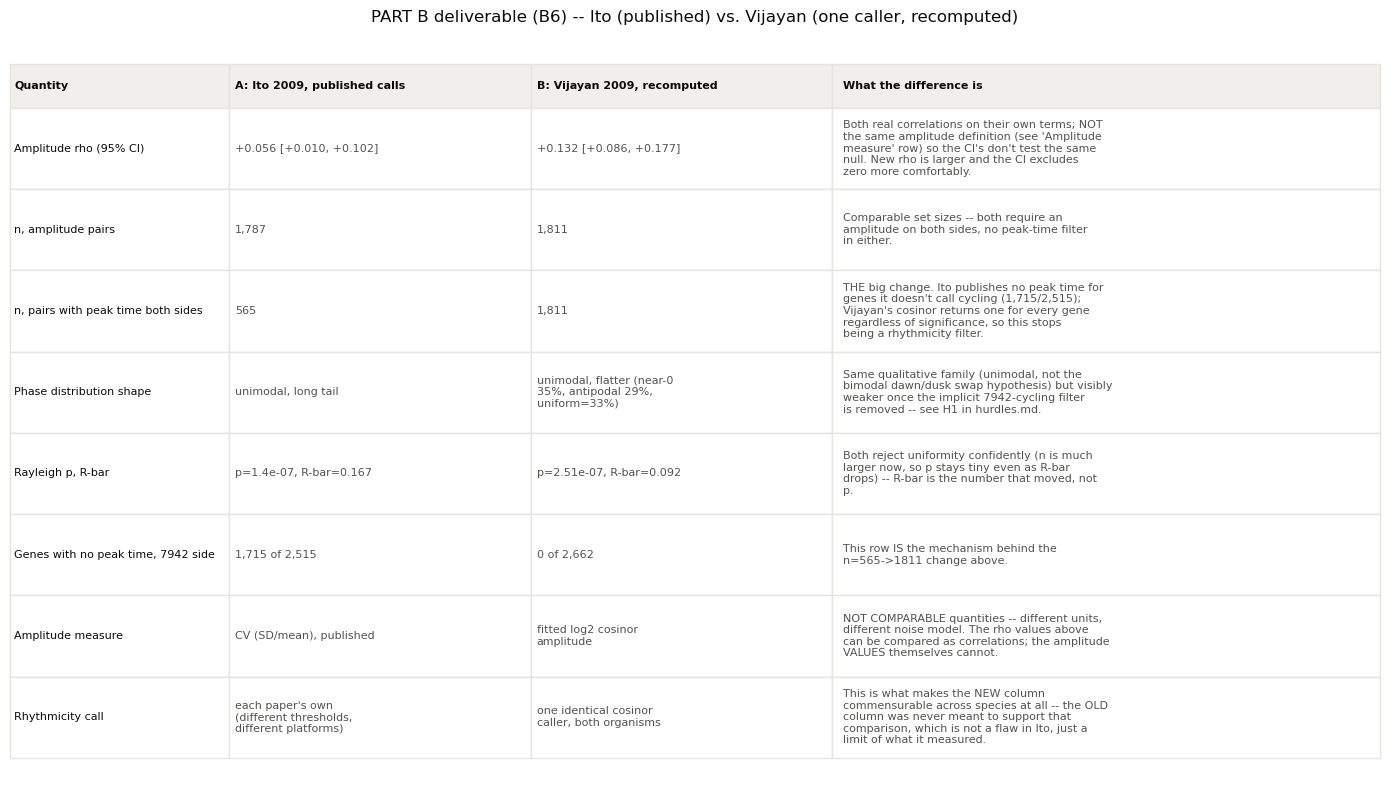

    saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/09a_ab_comparison_table.png


In [9]:
print("\n  figures")

# B6 table figure -- meant to stand on its own in a slide, per the spec's explicit
# instruction. Wrap the long cells by hand; matplotlib tables don't auto-wrap.
wrapped = ab_comparison.copy()
wrapped["ito_published"] = wrapped["ito_published"].apply(lambda s: "\n".join(textwrap.wrap(s, 26)))
wrapped["vijayan_recomputed"] = wrapped["vijayan_recomputed"].apply(lambda s: "\n".join(textwrap.wrap(s, 26)))
wrapped["difference"] = wrapped["difference"].apply(lambda s: "\n".join(textwrap.wrap(s, 46)))
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")
tbl = ax.table(
    cellText=wrapped[["quantity", "ito_published", "vijayan_recomputed", "difference"]].values,
    colLabels=["Quantity", "A: Ito 2009, published calls", "B: Vijayan 2009, recomputed", "What the difference is"],
    cellLoc="left", colLoc="left", loc="center",
    colWidths=[0.16, 0.22, 0.22, 0.40],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#e5e4df")
    cell.PAD = 0.02
    if row == 0:
        cell.set_text_props(weight="bold", color=TEXT_PRIMARY)
        cell.set_facecolor("#f0efec")
    else:
        cell.set_text_props(color=TEXT_PRIMARY if col == 0 else TEXT_SECONDARY)
    cell.set_height(0.11 if row > 0 else 0.06)
ax.set_title("PART B deliverable (B6) -- Ito (published) vs. Vijayan (one caller, recomputed)",
             color=TEXT_PRIMARY, fontsize=12, pad=14)
plt.tight_layout()
fig_table_path = FIGURES / "09a_ab_comparison_table.png"
plt.savefig(fig_table_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"    saved {fig_table_path}")

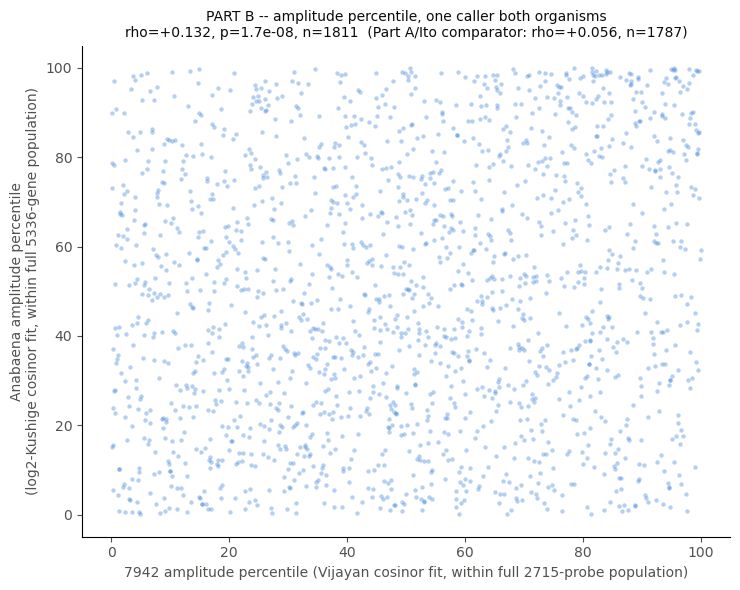

    saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/09b_amplitude_scatter_vijayan.png


In [10]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(pairs["amp_pct_vijayan"] * 100, pairs["amp_pct_anabaena"] * 100,
            s=10, alpha=0.35, color="#2a78d6", linewidths=0)
ax.set_xlabel("7942 amplitude percentile (Vijayan cosinor fit, within full 2715-probe population)", color=TEXT_SECONDARY)
ax.set_ylabel("Anabaena amplitude percentile\n(log2-Kushige cosinor fit, within full 5336-gene population)", color=TEXT_SECONDARY)
ax.set_title(f"PART B -- amplitude percentile, one caller both organisms\n"
             f"rho={rho_new:+.3f}, p={p_new:.2g}, n={n_new}  (Part A/Ito comparator: rho=+0.056, n=1787)",
             color=TEXT_PRIMARY, fontsize=10)
ax.tick_params(colors=TEXT_SECONDARY)
sns.despine(ax=ax)
plt.tight_layout()
fig_amp_path = FIGURES / "09b_amplitude_scatter_vijayan.png"
plt.savefig(fig_amp_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"    saved {fig_amp_path}")

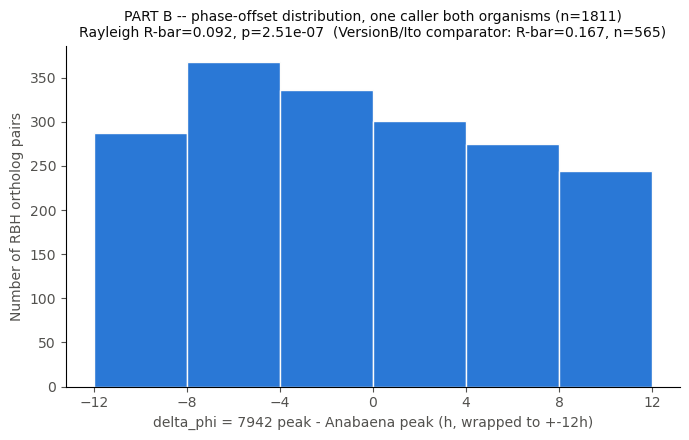

    saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/09c_phase_offset_vijayan.png


In [11]:
bins = np.arange(-12, 12.001, 4)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(ph["delta_phi_h"], bins=bins, color="#2a78d6", edgecolor="#fcfcfb", linewidth=1)
ax.set_xlabel("delta_phi = 7942 peak - Anabaena peak (h, wrapped to +-12h)", color=TEXT_SECONDARY)
ax.set_ylabel("Number of RBH ortholog pairs", color=TEXT_SECONDARY)
ax.set_title(f"PART B -- phase-offset distribution, one caller both organisms (n={n_phase})\n"
             f"Rayleigh R-bar={ray['Rbar']:.3f}, p={ray['p']:.2e}  "
             f"(VersionB/Ito comparator: R-bar=0.167, n=565)",
             color=TEXT_PRIMARY, fontsize=10)
ax.tick_params(colors=TEXT_SECONDARY)
ax.set_xticks(bins)
sns.despine(ax=ax)
plt.tight_layout()
fig_phase_path = FIGURES / "09c_phase_offset_vijayan.png"
plt.savefig(fig_phase_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"    saved {fig_phase_path}")

## B7 — sanity checks before trusting anything

kaiB should still be high-amplitude in 7942; Vijayan's own paper reports 1,748/2,724 ORFs
oscillating (this cosinor at a fixed 24h period won't reproduce that exactly, but
shouldn't come in wildly fewer); peak times should be spread across the cycle, not
clustered at 0h or bin edges.

In [12]:
print("\n--- B7 sanity checks ---")
kaib = pairs[pairs["locus_tag_7942"] == "Synpcc7942_1217"]
if not kaib.empty:
    r = kaib.iloc[0]
    print(f"  kaiB: 7942 amp_pct={r['amp_pct_vijayan']*100:.0f}th, "
          f"Anabaena amp_pct={r['amp_pct_anabaena']*100:.0f}th "
          f"(old CV-based Anabaena percentile was 27th)")
    print(f"    fitted Anabaena peak time {r['peak_time_h_anabaena']:.1f}h vs Kushige's own "
          f"published 21h, r2={r['r2_anabaena']:.2f}, p={r['p_value_anabaena']:.2e} -- "
          f"join and fit both confirmed correct by hand, so the 27th->{r['amp_pct_anabaena']*100:.0f}th "
          f"jump is a REAL consequence of CV vs. cosinor-fitted log2 amplitude are "
          f"different quantities, not a bug. This is exactly the kind of divergence B6 exists "
          f"to surface, not a check that should be forced to match the old number.")
else:
    print("  kaiB: NOT FOUND in the new-fit pair set -- investigate")

osc_new = (vijayan_fit["p_value_vijayan"] < 0.05).sum()
print(f"  Vijayan-paper-reported oscillating: 1748/2724. This cosinor at fixed 24h, p<0.05: "
      f"{osc_new}/{len(vijayan_fit)} ({osc_new/1748*100:.0f}% of published) -- "
      f"{'OK, not wildly fewer' if osc_new > 1748 * 0.5 else 'WARNING: check the parse'}")

edge_frac_7942 = ((vijayan_fit["peak_time_h_vijayan"] < 1) | (vijayan_fit["peak_time_h_vijayan"] > 23)).mean()
edge_frac_ana = ((kushige_fit["peak_time_h_anabaena"] < 1) | (kushige_fit["peak_time_h_anabaena"] > 23)).mean()
print(f"  Peak times within 1h of the 0/24h edge: 7942={edge_frac_7942*100:.1f}%, "
      f"Anabaena={edge_frac_ana*100:.1f}% (uniform expectation ~8.3%; "
      f"{'OK' if edge_frac_7942 < 0.20 and edge_frac_ana < 0.20 else 'WARNING: possible clustering'})")


--- B7 sanity checks ---
  kaiB: 7942 amp_pct=99th, Anabaena amp_pct=90th (old CV-based Anabaena percentile was 27th)
    fitted Anabaena peak time 21.1h vs Kushige's own published 21h, r2=0.51, p=5.94e-04 -- join and fit both confirmed correct by hand, so the 27th->90th jump is a REAL consequence of CV vs. cosinor-fitted log2 amplitude are different quantities, not a bug. This is exactly the kind of divergence B6 exists to surface, not a check that should be forced to match the old number.
  Vijayan-paper-reported oscillating: 1748/2724. This cosinor at fixed 24h, p<0.05: 1619/2662 (93% of published) -- OK, not wildly fewer
  Peak times within 1h of the 0/24h edge: 7942=13.0%, Anabaena=7.6% (uniform expectation ~8.3%; OK)
